###1- IA de previsao do clima com machining learning(open meteo)

In [ ]:
!pip install requests panda scikit-learn matplotlib google-generativeai --quiet

  Preparing metadata (setup.py) ... done


###2- Imports



In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import google.generativeai as genai

import requests
import string


In [ ]:
API_KEY = "YOUR_API_KEY"

def chamar_gemini(prompt):
    url = f" "

    body = {
        "contents": [
            {
                "parts": [{"text": prompt}]
            }
        ]
    }

    response = requests.post(url, json=body)
    data = response.json()

    if "candidates" in data:
        return data["candidates"][0]["content"]["parts"][0]["text"]
    else:
        return f"Erro Gemini: {data}"

###3- conversao de cidade para coordenadas


In [ ]:
def get_coordinates(city):
    url = "OPENMETEO_API_URL"

    params = {
        "name": city,
        "count": 10
    }

    response = requests.get(url, params=params)
    data = response.json()

    print("DEBUG:", data)

    if "results" not in data or len(data["results"]) == 0:
        return None

    for result in data["results"]:
        if result.get("country") == "Brazil":
            return result["latitude"], result["longitude"]

    result = data["results"][0]
    return result["latitude"], result["longitude"]

###4- Baixar dados historicos

In [ ]:
def get_historical_data(lat, lon):
  url = "OPENMETEO_API_URL"

  params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2023-01-01",
        "end_date": "2023-12-31",
        "daily": "temperature_2m_max,temperature_2m_min",
        "timezone": "auto"
    }

  data = requests.get(url, params=params).json()

  df = pd.DataFrame({
      "date": data["daily"]["time"],
      "temp_max": data["daily"]["temperature_2m_max"],
      "temp_min": data["daily"]["temperature_2m_min"]
  })

  return df

###5- Preparacao de dados

In [ ]:
def preparar_dados(df):
  df["date"] = pd.to_datetime(df["date"])
  df["day"] = df["date"].dt.day
  df["month"] = df["date"].dt.month

  X = df[["day", "month", "temp_min"]]
  Y = df["temp_max"]

  return train_test_split(X, Y,test_size=0.2, random_state=42)

###6- Treinar modelo

In [ ]:
def treinar_modelo(X_train, Y_train):
  modelo_ml = LinearRegression()
  modelo_ml.fit(X_train, Y_train)
  return modelo_ml

###7- Avaliacao do modelo

In [ ]:
def avaliar_modelo(model, X_test, Y_test):
  preds = model.predict(X_test)

  mse = mean_squared_error(Y_test, preds)
  r2 = r2_score(Y_test, preds)

  print("Erro (mse): ", mse)
  print("Acuracia (r2): ", r2)

###8- Previsao

In [ ]:
def prever(model, day, month, temp_min):
  pred = model.predict([[day, month, temp_min]])
  return pred[0]

###9- Execucao

In [ ]:
cidade = "Belem"

coords = get_coordinates(cidade)

if coords:
  lat, lon = coords

  df = get_historical_data(lat, lon)

  X_train, X_test, Y_train, Y_test = preparar_dados(df)

  modelo_ml = treinar_modelo(X_train, Y_train)
  avaliar_modelo(modelo_ml, X_test, Y_test)

  print("previsao: ", prever(modelo_ml, 15, 6, 24))

else: print("cidade nao encontrada")

DEBUG: {'results': [{'id': 3405870, 'name': 'Belém', 'latitude': -1.45583, 'longitude': -48.50444, 'elevation': 15.0, 'feature_code': 'PPLA', 'country_code': 'BR', 'admin1_id': 3393129, 'admin2_id': 6319377, 'timezone': 'America/Belem', 'population': 1499641, 'country_id': 3469034, 'country': 'Brazil', 'admin1': 'Pará', 'admin2': 'Belém'}, {'id': 5456975, 'name': 'Belen', 'latitude': 34.66284, 'longitude': -106.77642, 'elevation': 1466.0, 'feature_code': 'PPL', 'country_code': 'US', 'admin1_id': 5481136, 'admin2_id': 5496319, 'timezone': 'America/Denver', 'population': 7152, 'postcodes': ['87002'], 'country_id': 6252001, 'country': 'United States', 'admin1': 'New Mexico', 'admin2': 'Valencia'}, {'id': 2270978, 'name': 'Belém Tower', 'latitude': 38.69875, 'longitude': -9.19289, 'elevation': 13.0, 'feature_code': 'PPL', 'country_code': 'PT', 'admin1_id': 2267056, 'admin2_id': 6458923, 'admin3_id': 12573305, 'timezone': 'Europe/Lisbon', 'population': 16546, 'country_id': 2264397, 'country

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


###10- Grafico

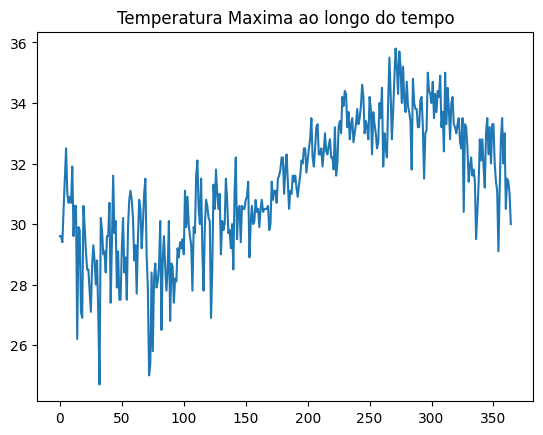

In [ ]:
plt.plot(df["temp_max"])
plt.title("Temperatura Maxima ao longo do tempo")
plt.show()

###11- Aplicacao do gemini


In [ ]:
import requests
import string

def get_weather(lat, lon):
    url = "OPENMETEO_API_URL"
    params = {"latitude": lat, "longitude": lon, "current_weather": True}

    data = requests.get(url, params=params).json()

    if "current_weather" not in data:
        return None

    weather = data["current_weather"]

    return {
        "temp": weather["temperature"],
        "wind": weather["windspeed"],
        "code": weather["weathercode"]
    }


def responder_clima_gemini(cidade):
    coords = get_coordinates(cidade)

    if not coords:
        return "Não encontrei essa cidade 😕"

    lat, lon = coords
    clima = get_weather(lat, lon)

    if not clima:
        return "Erro ao pegar clima 😕"

    prompt = f"""
Explique o clima atual de forma simples.

Cidade: {cidade}
Temperatura: {clima['temp']}°C
Vento: {clima['wind']} km/h
Código: {clima['code']}
"""

    try:
        return chamar_gemini(prompt)
    except Exception as e:
        return f"Erro Gemini: {e}"


def chat():
    print("Agente de clima iniciado! (digite 'sair')\n")

    while True:
        pergunta = input("Você: ")

        if pergunta.lower() == "sair":
            break

        cidade = pergunta.split()[-1].strip(string.punctuation).capitalize()

        resposta = responder_clima_gemini(cidade)

        print("\nAgente:", resposta, "\n")


chat()

Agente de clima iniciado! (digite 'sair')

Você: clima em macapa
DEBUG: {'results': [{'id': 3396016, 'name': 'Macapá', 'latitude': 0.03889, 'longitude': -51.06639, 'elevation': 17.0, 'feature_code': 'PPLA', 'country_code': 'BR', 'admin1_id': 3407762, 'admin2_id': 6319498, 'timezone': 'America/Belem', 'population': 512902, 'country_id': 3469034, 'country': 'Brazil', 'admin1': 'Amapá', 'admin2': 'Macapá'}, {'id': 3396009, 'name': 'Macaparana', 'latitude': -7.55472, 'longitude': -35.45306, 'elevation': 347.0, 'feature_code': 'PPL', 'country_code': 'BR', 'admin1_id': 3392268, 'admin2_id': 6320543, 'timezone': 'America/Recife', 'population': 14362, 'country_id': 3469034, 'country': 'Brazil', 'admin1': 'Pernambuco', 'admin2': 'Macaparana'}, {'id': 1042844, 'name': 'Macápa', 'latitude': -23.95194, 'longitude': 32.31833, 'elevation': 82.0, 'feature_code': 'PPL', 'country_code': 'MZ', 'admin1_id': 1046058, 'timezone': 'Africa/Maputo', 'country_id': 1036973, 'country': 'Mozambique', 'admin1': 'G